# Estimação de Preço de Veículos Usados: EDA

---

- **Autor:** Lucas Bressanin
- **Entrega:** 12/09/2026 - Parte 1
- **Objetivo:** Estimar o `selling_price` dos veículos usando regressão 

##### Importação do dataset escolhido (https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho)

In [57]:
import pandas as pd

# carregando o dataset a partir do csv
df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")

df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner


##### Verificação dos números de instâncias e features

In [58]:
# extraindo o número de instâncias (linhas) e features (colunas)
row, cols = df.shape

print(f"instâncias: {row} features: {cols}")

instâncias: 4340 features: 8


### Análise das Features do Dataset

| Feature | Descrição | Tipo |
| --- | --- | --- |
| `name` | Nome/modelo do carro | Categórico  |
| `year` | Ano em que o carro foi comprado | Numérico  |
| `selling_price` | Preço pelo qual o carro está anunciado | Numérico |
| `km_driven` | Quilometragem rodada pelo carro | Numérico |
| `fuel` | Tipo de combustível do carro | Categórico |
| `seller_type` | Se o vendedor é um indivíduo ou uma loja | Categórico |
| `transmission` | Se o câmbio é manual ou automático | Categórico |
| `owner` | Quantidade de donos anteriores do carro | Categórico |

#### Verificação de valores faltantes

In [59]:
# contando valores nulos por coluna
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

##### Nesse caso demos sorte de não haver nenhum valor faltante

#### Verificação de desbalanceamento entre as classes categóricas 

In [60]:
# colunas categóricas a verificar
cols = ['fuel', 'seller_type', 'transmission', 'owner']

# frequência absoluta de cada categoria, pra identificar desbalanceamento
for col in cols:
    print(df[col].value_counts())
    print()

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64

transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64



#### Pode-se notar alguns fatos interessantes: 
- Praticamente 100% dos veículos são Diesel ou Gasolina, sendo Diesel pouco superior
- Grande parte dos veículos estão sendo vendidos de forma individual 
- A maior parte dos veículos é manual
- A maior parte dos veículos anunciados são de único dono

#### Antes de prosseguir para as análises univariadas, vamos separar os dados de treino e os dados de teste para evitar qualquer tipo de vazamento

In [61]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["selling_price"]) # removendo o target do resto dos dados
y = df["selling_price"] # separando o target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 
# random_state -> travando a seed para separar igualmente em outras máquinas

#### Vamos analisar as variáveis numéricas (`year`, `km_driven`, `selling_price`) primeiramente de forma univariada

In [62]:
# estatísticas descritivas das features numéricas (usando só o treino, pra evitar data leakage)
df_treino_features_stats = X_train.describe().round(2) # analisando as features
df_treino_features_stats

,year,km_driven
count,3472.00,3472.00
mean,2013.12,66014.13
std,4.21,46905.39
min,1992.00,1.00
25%,2011.00,35000.00
50%,2014.00,60000.00
75%,2016.00,90000.00
max,2020.00,806599.00


In [63]:
# estatísticas descritivas do target (só o treino)
df_treino_target_stats = y_train.describe().round(2) # analisando o target

df_treino_target_stats

count       3472.00
mean      507767.47
std       584843.21
min        22000.00
25%       210000.00
50%       350000.00
75%       600000.00
max      8150000.00
Name: selling_price, dtype: float64

#### Histogramas das variáveis numéricas

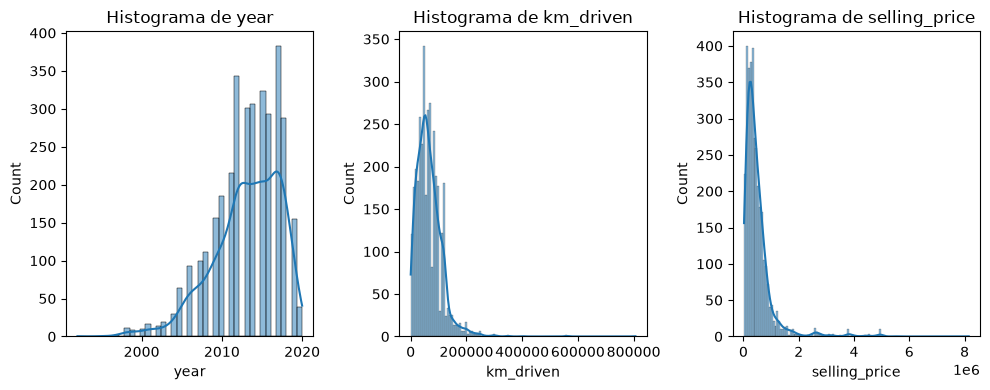

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns


numeric_cols = ["year", "km_driven"]

# reunindo features e target de treino num único df, só para plotagem
train_df = X_train.copy()
train_df["selling_price"] = y_train

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

# histograma + curva de densidade (kde) de cada variável numérica
for ax, col in zip(axes, numeric_cols + ["selling_price"]):
    sns.histplot(data=train_df, x=col, kde=True, ax=ax)
    ax.set_title(f"Histograma de {col}")

plt.tight_layout()
plt.show()

#### Boxplots das variáveis numéricas

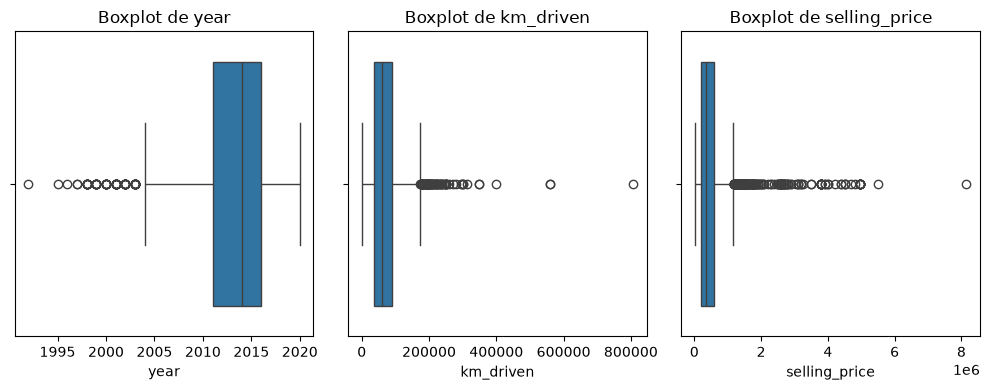

In [65]:
# boxplot de cada variável numérica, pra visualizar dispersão e outliers
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for ax, col in zip(axes, numeric_cols + ["selling_price"]):
    sns.boxplot(data=train_df, x=col, ax=ax)
    ax.set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

#### Fatos analisados

- Os histogramas revelam:

    - O ano dos veículos apresenta uma cauda a esquerda
        - A maior parte dos veículos são de 2000 para frente 
    - A kilometragem e o preço apresentam cauda a direita
        - A maior parte dos veículos custa menos de 2M
        - A maior parte dos veículos tem menos de 200.000 Km
- Os boxplots revelam:

    - Dentro de ano, os outliers são os carros mais **antigos** e a mediana é 2014
    - Apesar da caixa ficar distorcida em kilometragem por conta dos outliers, a mediana está em 60.000 km
    - O valor alto no preço dos carros se deve a moeda do país em que os carros estão anunciados, que nesse caso são as **rúpias indianas (INR)**. A mediana fica em 350.000 rúpias


#### Vamos analisar de forma bivariada as variáveis numéricas começando pelas correlações

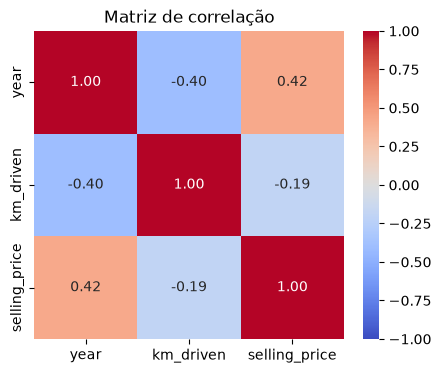

In [66]:
# matriz de correlação de Pearson entre as variáveis numéricas (treino)
corr_matrix = train_df.corr(numeric_only=True)

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlação")
plt.show()

##### Podemos ver que nenhuma correlação é forte (≥0.7 ou ≤-0.7). As mais notáveis são: year e selling_price (0.42, correlação positiva fraca/moderada — carros mais novos tendem a custar mais) e year e km_driven (-0.40, correlação negativa fraca/moderada — carros mais novos têm menos km rodados). km_driven e selling_price têm correlação praticamente desprezível (-0.19).

#### Agora com Scatter plots

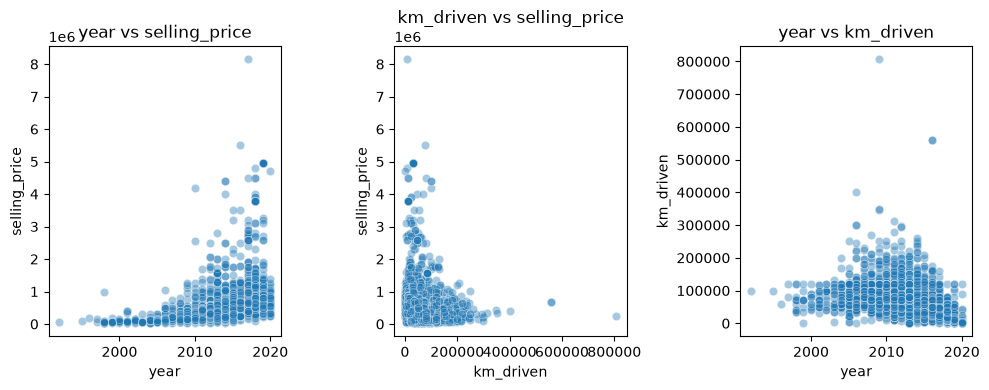

In [67]:
# pares de variáveis numéricas a comparar via scatter plot
pairs = [("year", "selling_price"), ("km_driven", "selling_price"), ("year", "km_driven")]

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for ax, (x_col, y_col) in zip(axes, pairs):
    sns.scatterplot(data=train_df, x=x_col, y=y_col, alpha=0.4, ax=ax)
    ax.set_title(f"{x_col} vs {y_col}")

plt.tight_layout()
plt.show()

#### Podemos fazer algumas análises:

- Quanto mais novo um veículo, mais caro ele tende a ser
    - A dispersão dos preços aumenta bastante nos carros mais recentes (pós-2015), enquanto os mais antigos ficam concentrados perto de zero 
- Quanto menos rodado, mais caro ele tende a ser
    - A relação não parece linear: o preço cai rápido nos primeiros km rodados e depois achata, lembrando mais uma curva de decaimento do que uma reta
- Não necessariamente quanto mais novo, menos rodado o veículo é
    - O outlier de ~800.000 km aparece numa faixa intermediária de anos, não nos carros mais antigos, reforçando que não há uma relação limpa entre as duas variáveis

Isso acaba batendo bastante com o que a matriz de correlação mostra

#### Vamos analisar a relação entre as variáveis categóricas e o target (`selling_price`)

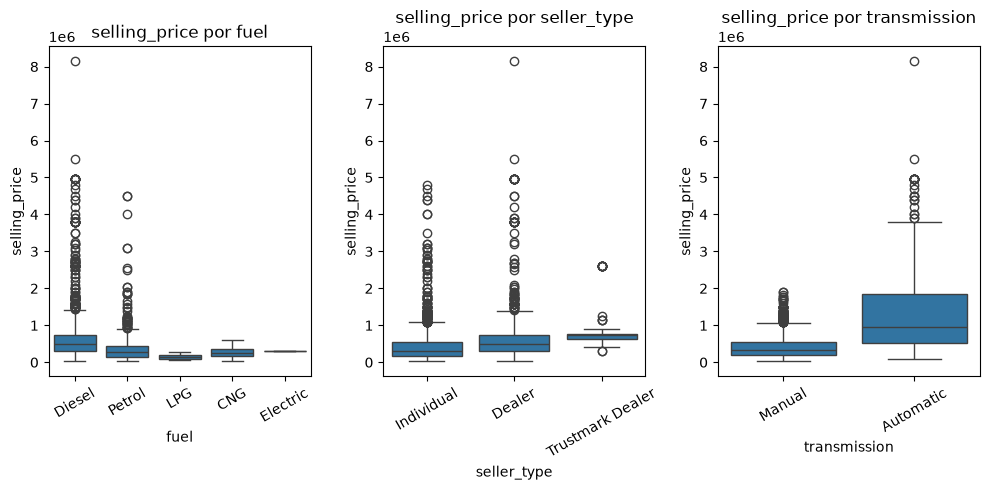

In [68]:
# colunas categóricas a comparar com o target
cat_vs_target_cols = ["fuel", "seller_type", "transmission"]

# boxplot do selling_price agrupado por cada categoria
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for ax, col in zip(axes, cat_vs_target_cols):
    sns.boxplot(data=train_df, x=col, y="selling_price", ax=ax)
    ax.set_title(f"selling_price por {col}")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

#### Análises feitas:

- Podemos ver que os carros diesel são mais caros que os outros
    - Os carros diesel têm uma dispersão bem maior que o resto
    - Fora os carros a gasolina, o resto possui amostras muito pequenas. Elétrico por exemplo existe apenas 1 amostra
- Carros vendidos por Trustmark Dealers são mais caros
    - Trustmark Dealers não possuem outliers extremos
    - Dealers têm o maior desvio padrão, chegando a valores mais baratos e os mais caros do dataset
- Carros automáticos são bem mais caros
    - Possuem os preços mais imprevisíveis/dispersos considerando que são apenas 10% das amostras


#### Vamos analisar a relação entre variáveis numéricas e categóricas usando boxplots conjuntos

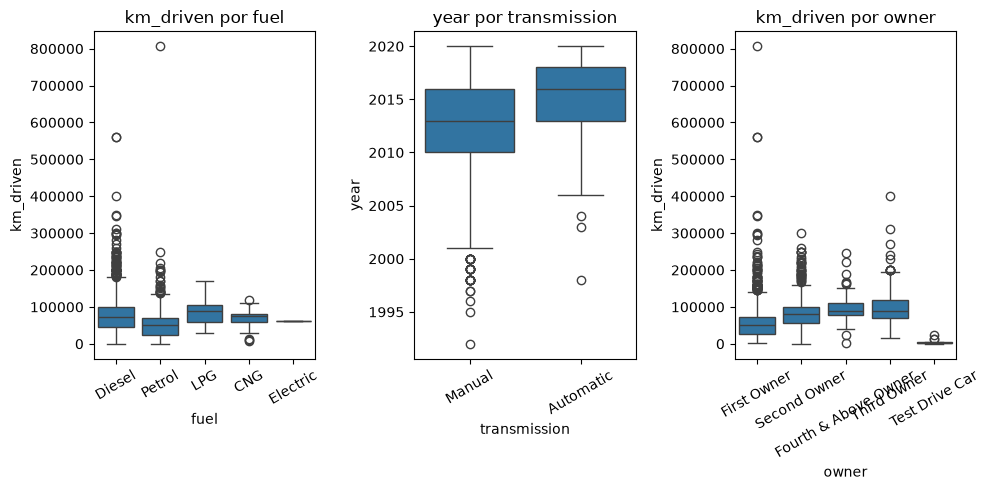

In [69]:
# pares (categórica, numérica) a analisar via boxplot conjunto
num_vs_cat_pairs = [("fuel", "km_driven"), ("transmission", "year"), ("owner", "km_driven")]

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for ax, (cat_col, num_col) in zip(axes, num_vs_cat_pairs):
    sns.boxplot(data=train_df, x=cat_col, y=num_col, ax=ax)
    ax.set_title(f"{num_col} por {cat_col}")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

#### Análises feitas:

- Os carros de maior km são os fuel do tipo LPG (combustível fóssil) - (fora os outliers dos outros), embora seja uma amostra pequena (apenas 18 carros)
    - Novamente os carros a diesel têm uma dispersão muito grande, nesse caso também para kilometragem
- Os carros automáticos se tornam mais presentes depois de ~2010
- Os carros menos rodados são os de test drive e os mais rodados são os que passaram por mais de 3 donos
    

### Pré-Processamento 
---------------------------------

- No caso desse dataset, não precisaremos lidar com nenhuma imputação a respeito de dados faltantes, como conferido no início do EDA

- Sobre outliers, não vale a pena remover, tendo em vista que, por exemplo, um carro caro vai estar vinculado a uma marca/modelo específico que nosso modelo precisa aprender a **estimar** corretamente. Uma quilometragem alta também não deve ser removida, já que provavelmente representa um carro usado para trabalho (ex: táxi), sendo uma informação real e não um erro.
     - Como estratégia, optei por manter os outliers e aplicar uma transformação logarítmica no target `selling_price` para reduzir a **assimetria** e a **heterocedasticidade (variância/dispersão dos dados não constante)** observadas na análise univariada, em vez de removê-los.
     
     - E para as variáveis numéricas `km_driven` e `year` vou utilizar um RobustScaler, que utiliza a mediana e os quartis para ser resistente a outliers

- Para encoding de variáveis categóricas:

    - `transmission`: possui apenas 2 categorias (Manual, Automatic) sem nenhuma ordem entre elas, então **one-hot encoding** resolve bem, gerando uma única coluna binária.

    - `fuel` e `seller_type`: apesar de terem poucas categorias, elas não possuem uma ordem/hierarquia natural entre si (ex: não faz sentido dizer que Diesel > Petrol, ou que Dealer > Individual). Usar label/ordinal encoding introduziria uma relação de distância artificial entre as categorias, o que pode enviesar modelos lineares/baseados em distância. Por isso, vou usar **one-hot encoding** nas duas.

    - `owner`: diferente das anteriores, existe uma progressão real entre as categorias (First Owner < Second Owner < Third Owner < Fourth & Above Owner), então faz sentido usar **ordinal encoding**. O único cuidado é com "Test Drive Car", que não representa um dono de fato — vou tratá-lo como o valor mais baixo da escala (0), antes de "First Owner".

    - `name`: como o campo tem cardinalidade altíssima (praticamente cada linha é um valor único), qualquer encoding direto causaria overfitting seríssimo. Em vez disso, vou extrair a **marca** do carro (primeira palavra do nome, ex: "Maruti", "Hyundai", "BMW"), reduzindo de milhares de valores únicos para apenas 29 marcas. Como ainda existem marcas raríssimas (com 1 a 6 ocorrências, ex: Kia, Isuzu, Daewoo), pretendo agrupá-las numa categoria "Other" antes de aplicar **one-hot encoding**, evitando colunas extremamente esparsas.

- Para escalonamento de variáveis numéricas: 

     - Para as duas features numéricas `year` e `km_driven`, vou usar RobustScaler, como mencionado na parte de outliers, para não sofrer muito com as dispersões/outliers dos dados  

- Testando uso de redução de dimensionalidade

In [70]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

# escalonando as variáveis numéricas - obrigatório já que o PCA analisa variancia, logo
# os dados precisam estar na mesma escala -  que vamos testar reduzir (ou não)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train[["year", "km_driven"]])

# aplicando PCA para reduzir a duas componentes principais
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

print("Variância explicada por componente:", pca.explained_variance_ratio_)
print("Variância total explicada (PC1 + PC2):", pca.explained_variance_ratio_.sum())

Variância explicada por componente: [0.70247192 0.29752808]
Variância total explicada (PC1 + PC2): 1.0


Nesse caso, não há motivo para aplicar redução de dimensionalidade, já que já estamos trabalhando com apenas 2 variáveis numéricas — o PCA existe justamente para reduzir muitas dimensões para poucas, e aqui não há "muitas" dimensões pra começar. Ao rodar PCA(n_components=2), a soma das variâncias explicadas é sempre 100% (não houve redução real, apenas uma rotação dos eixos); reduzir para 1 componente perderia quase 30% da variância, o que também não compensaria.

### Construção do Pipeline seguindo o que foi definido no Pré-Processamento
----------------

In [71]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
import numpy as np 

numeric = ['year', 'km_driven'] #separando as colunas numéricas
nominal = ['fuel', 'seller_type', 'transmission'] #categóricas sem ordem natural
ordinal = ['owner'] #categórica com ordem natural
name_col = ['name'] #precisa de extração da marca antes do encoding

# ordem das categorias de owner (Test Drive Car = 0 donos, não é bem um "dono")
owner_order = ["Test Drive Car", "First Owner", "Second Owner", "Third Owner", "Fourth & Above Owner"]


def extract_brand(X):
    # X chega como DataFrame com uma coluna (name); extrai a 1a palavra e agrupa marcas raras
    brands = X.iloc[:, 0].str.split().str[0]
    rare_brands = brands.value_counts()[lambda s: s < 10].index
    brands = brands.where(~brands.isin(rare_brands), "Other")
    return brands.to_frame(name="brand")


# pipeline exclusivo para name: extrai a marca e depois aplica one-hot encoding, como decidido 
# para evitar overfitting
name_pipeline = Pipeline([
    ('extract_brand', FunctionTransformer(extract_brand)),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

# ColumnTransformer final: aplica cada transformação na sua respectiva coluna
preprocess = ColumnTransformer([
    ('num', RobustScaler(), numeric), # escalonamento robusto das numéricas
    ('nominal', OneHotEncoder(handle_unknown='ignore'), nominal), # one-hot nas categóricas sem ordem
    ('ordinal', OrdinalEncoder(categories=[owner_order]), ordinal), # ordinal encoding respeitando a ordem definida
    ('name', name_pipeline, name_col), # extração de marca + one-hot
])

### Tranformação do target
y_train_log = np.log1p(y_train)  # transforma antes de treinar


pipe = Pipeline([
    ('preprocess', preprocess)
])

pipe.fit_transform(X_train)

display(pipe)

#-----------------------------------------------------------------------------------------#
#   Próximo passos: adicionar o modelo após o preprocess e realizar o fit no y_train_log


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['name','year','km_driven',...,'seller_type','transmission','owner']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenate

## Relatório Final da EDA

### Sobre o dataset

O dataset (CarDekho, Kaggle) contém **4340 instâncias e 8 features** sobre veículos usados anunciados na Índia. O objetivo é estimar o `selling_price` (preço de venda, em **rúpias indianas — INR**) a partir das demais variáveis, num problema de **regressão**. Não há nenhum valor ausente no dataset.

### Principais achados

**Univariada:**
- `year`, `km_driven` e `selling_price` apresentam distribuições assimétricas: `year` com cauda à esquerda (maioria dos veículos de 2000 em diante), enquanto `km_driven` e `selling_price` têm cauda à direita.
- As variáveis categóricas são desbalanceadas: quase 100% dos veículos são Diesel/Petrol (CNG, LPG e Electric são raríssimos); a maioria é vendida por indivíduos, é manual, e teve apenas 1 dono.

**Bivariada/Multivariada:**
- Nenhuma correlação entre as numéricas é forte (todas abaixo de |0.42|). As mais notáveis: `year`×`selling_price` (0.42) e `year`×`km_driven` (-0.40).
- Carros mais novos e com menor quilometragem tendem a ser mais caros, mas a relação `km_driven`×`selling_price` não é linear (parece uma curva de decaimento) e há heterocedasticidade em `year`×`selling_price` (dispersão de preços cresce nos carros mais recentes).
- Entre as categóricas: carros a Diesel, vendidos por Trustmark Dealers e com câmbio automático tendem a ser bem mais caros — automáticos chegam a ter mediana quase 3x maior que manuais.
- Os outliers de preço (carros de marcas premium como Audi, BMW, Mercedes-Benz) e de quilometragem (~800.000 km) são valores reais do mercado, não erros de coleta.

### Estratégia de pré-processamento definida

- **Valores ausentes:** nenhuma imputação necessária (dataset sem nulos).
- **Outliers:** mantidos (representam segmentos reais de mercado). Para reduzir o impacto da assimetria/heterocedasticidade, aplicamos **transformação logarítmica (`np.log1p`)** no target `selling_price`.
- **Escalonamento:** `RobustScaler` em `year` e `km_driven`, por serem menos sensíveis a outliers que Min-Max/Standardization.
- **Encoding categórico:**
    - One-hot: `fuel`, `seller_type`, `transmission` (sem ordem natural entre categorias).
    - Ordinal: `owner` (existe progressão real entre as categorias).
    - `name`: reduzido para **marca** (primeira palavra), agrupando marcas raras (<10 ocorrências) em "Other", e então one-hot encoded — evita overfitting da altíssima cardinalidade original.
- **Redução de dimensionalidade (PCA):** testada nas 2 variáveis numéricas brutas e descartada — não há benefício em reduzir dimensão de um espaço que já é 2D.
- **Pipeline:** todo o pré-processamento das features foi implementado com `ColumnTransformer` + `Pipeline` do scikit-learn, validado com `fit_transform` sobre o conjunto de treino.

### Próximos passos (Parte 2 — Modelagem)

- Treinar modelos de regressão usando `X_train` (após `preprocess`) e `y_train_log` como target.
- Reverter as previsões para a escala original com `np.expm1` antes de avaliar métricas de erro.
- Avaliar se `TransformedTargetRegressor` é uma alternativa mais robusta para encapsular a transformação log do target dentro do próprio modelo.